In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats 
warnings.filterwarnings('ignore')

In [6]:
#Load the dataset
conn = sqlite3.connect('inventory.db')

#Fetching the data from vendor_sales_summary table
df = pd.read_sql_query("""select * from Vendor_sales_summary""",conn)
df.head()


,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.30,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.06,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.68,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.14,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.41,0.983556,1.396897


Exploratory Data Analysis

Previously, we examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.   

In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.

In [12]:
#statistical distribution
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.00,10650.65,18753.52,2.00,3951.00,7153.00,9552.00,201359.00
Brand,10692.00,18039.23,12662.19,58.00,5793.50,18761.50,25514.25,90631.00
PurchasePrice,10692.00,24.39,109.27,0.36,6.84,10.46,19.48,5681.81
ActualPrice,10692.00,35.64,148.25,0.49,10.99,15.99,28.99,7499.99
Volume,10692.00,847.36,664.31,50.00,750.00,750.00,750.00,20000.00
TotalPurchaseQuantity,10692.00,3140.89,11095.09,1.00,36.00,262.00,1975.75,337660.00
TotalPurchaseDollars,10692.00,30106.69,123067.80,0.71,453.46,3655.47,20738.25,3811251.60
TotalSalesQuantity,10692.00,3077.48,10952.85,0.00,33.00,261.00,1929.25,334939.00
TotalSalesDollars,10692.00,42239.07,167655.27,0.00,729.22,5298.05,28396.92,5101919.51
TotalSalesPrice,10692.00,18793.78,44952.77,0.00,289.71,2857.80,16059.56,672819.31


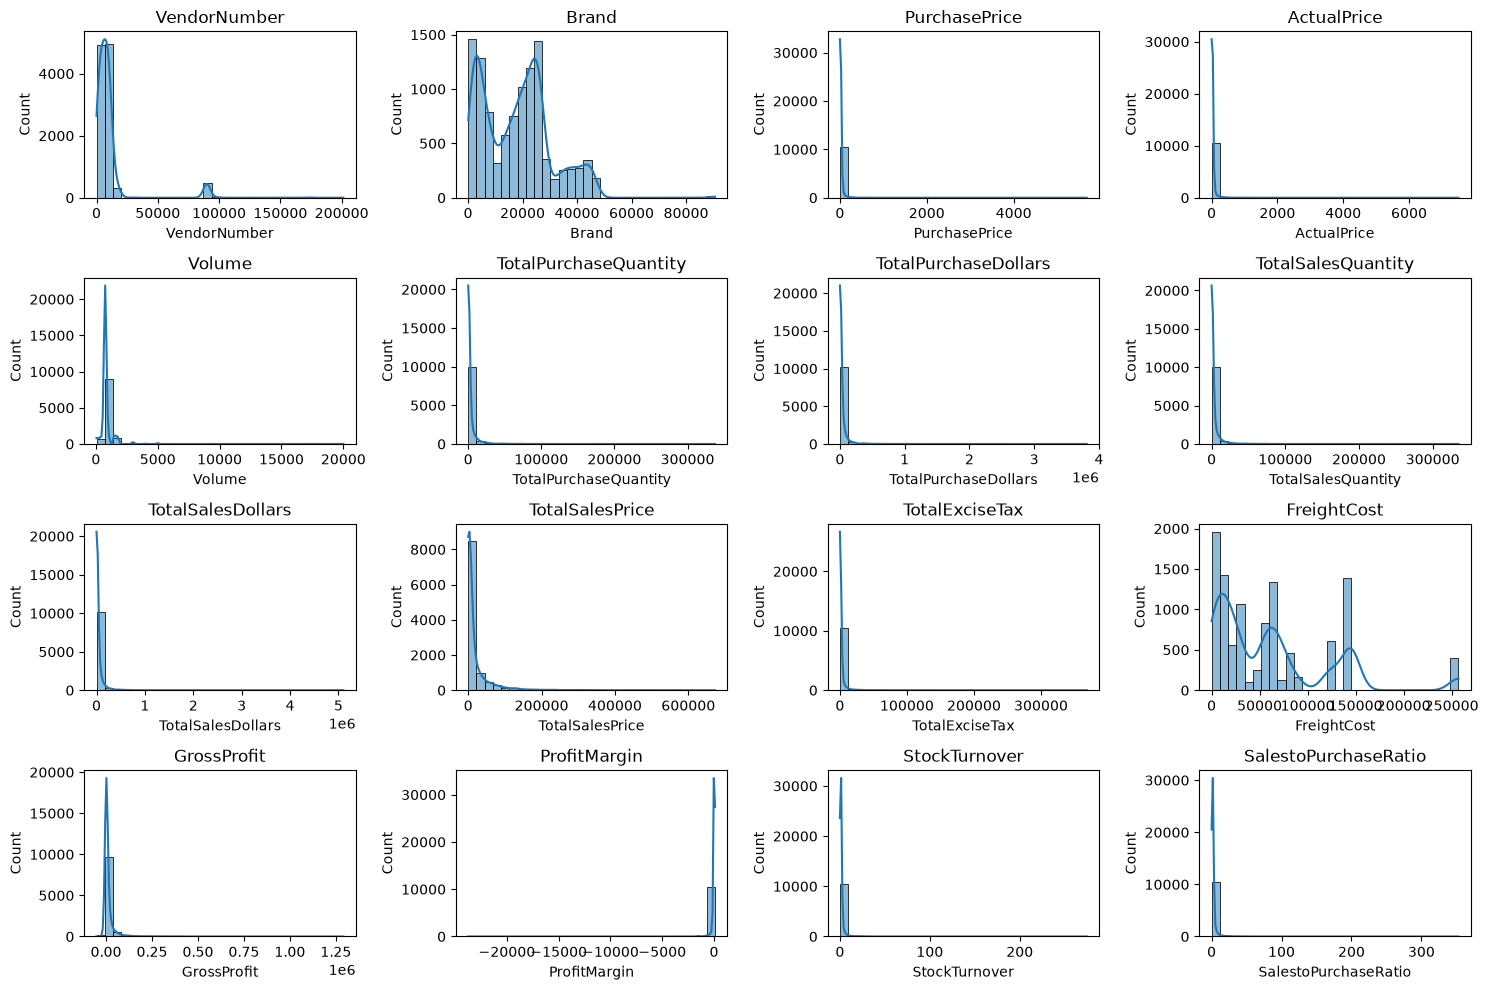

In [14]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)  # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

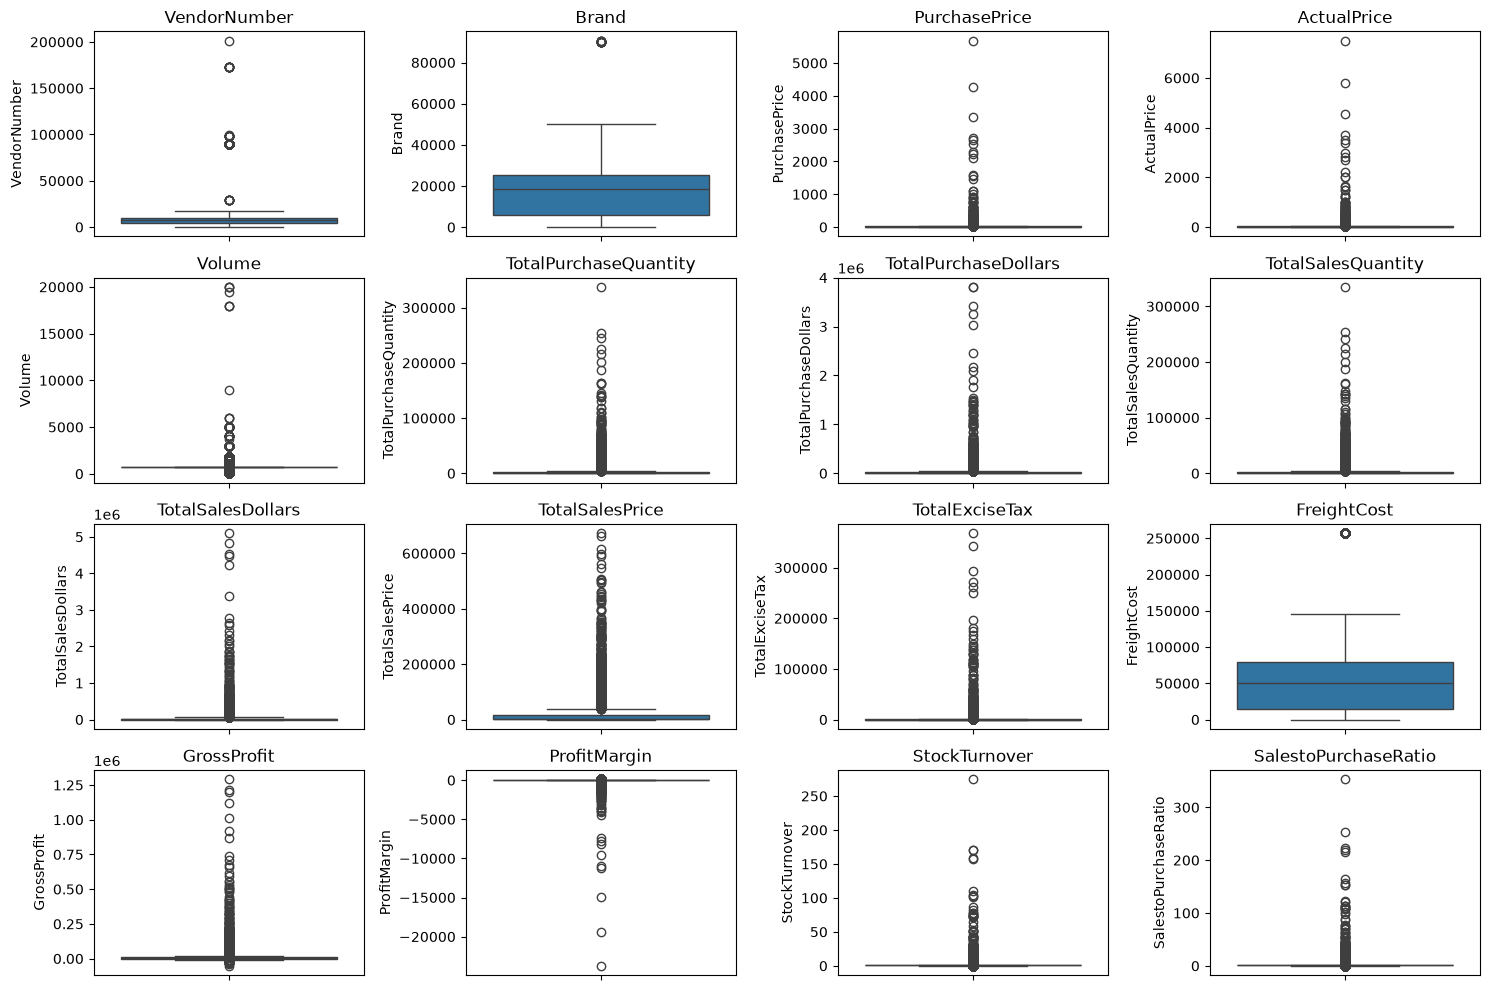

In [15]:
# Outlier Detection with Boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

### Summary Statistics Insights:

**Negative & Zero Values:**

* Gross Profit: Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price..
* Profit Margin: Has a minimum of -∞, which suggests cases where revenue is zero or even lower than costs.
* Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

**Outliers Indicated by High Standard Deviations:**

* Purchase & Actual Prices: The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.
* Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
* Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that Sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.

In [16]:
df.columns

Index(['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePrice',
       'ActualPrice', 'Volume', 'TotalPurchaseQuantity',
       'TotalPurchaseDollars', 'TotalSalesQuantity', 'TotalSalesDollars',
       'TotalSalesPrice', 'TotalExciseTax', 'FreightCost', 'GrossProfit',
       'ProfitMargin', 'StockTurnover', 'SalestoPurchaseRatio'],
      dtype='str')

In [18]:
#clearing out the negative values and some unnecessary outliers
df = pd.read_sql_query(""" select * from vendor_sales_summary 
                                where GrossProfit >0 and 
                                      ProfitMargin>0 and
                                      TotalSalesQuantity >0 """, conn)


In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,8564.00,10107.07,17635.71,2.00,3664.00,7153.00,9552.00,201359.00
Brand,8564.00,17614.67,12946.13,58.00,5375.75,17606.00,24935.25,90631.00
PurchasePrice,8564.00,21.78,81.19,0.36,6.66,10.06,17.85,3352.93
ActualPrice,8564.00,32.30,112.42,0.49,9.99,14.99,25.99,4559.99
Volume,8564.00,864.33,724.24,50.00,750.00,750.00,750.00,20000.00
TotalPurchaseQuantity,8564.00,3772.01,12276.96,1.00,42.00,431.00,2666.75,337660.00
TotalPurchaseDollars,8564.00,35887.25,136723.00,0.71,546.19,5018.40,26610.18,3811251.60
TotalSalesQuantity,8564.00,3748.98,12125.70,1.00,62.00,490.50,2675.00,334939.00
TotalSalesDollars,8564.00,51542.28,186071.49,1.98,1355.58,8483.78,40622.11,5101919.51
TotalSalesPrice,8564.00,22759.27,49305.27,0.99,584.79,4549.76,22595.25,672819.31


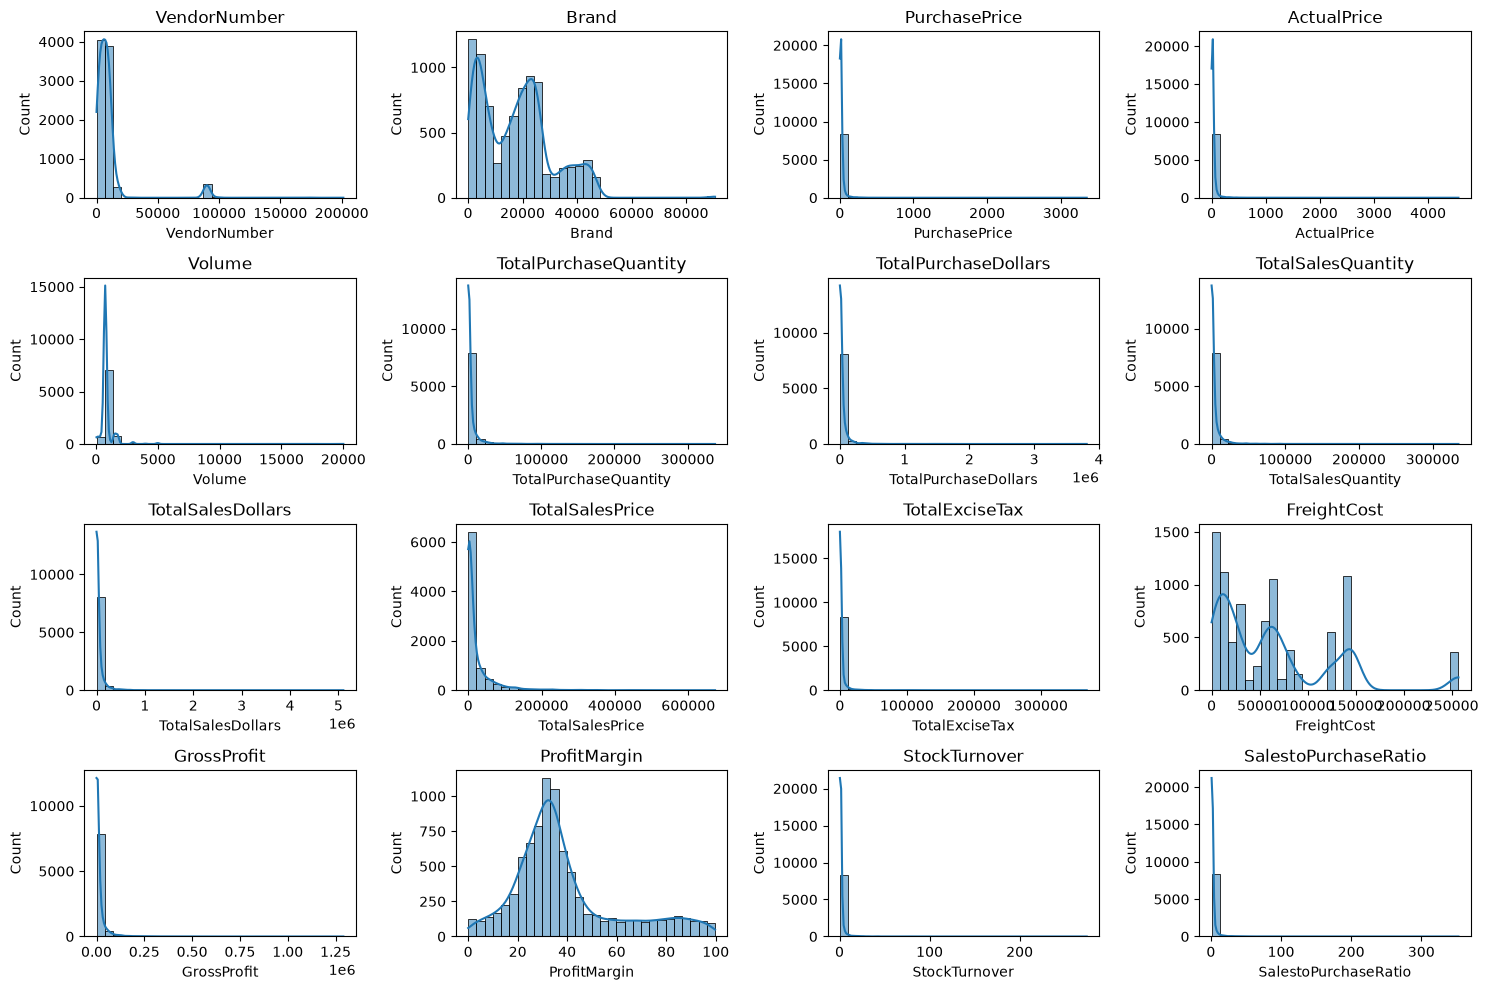

In [20]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)  # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

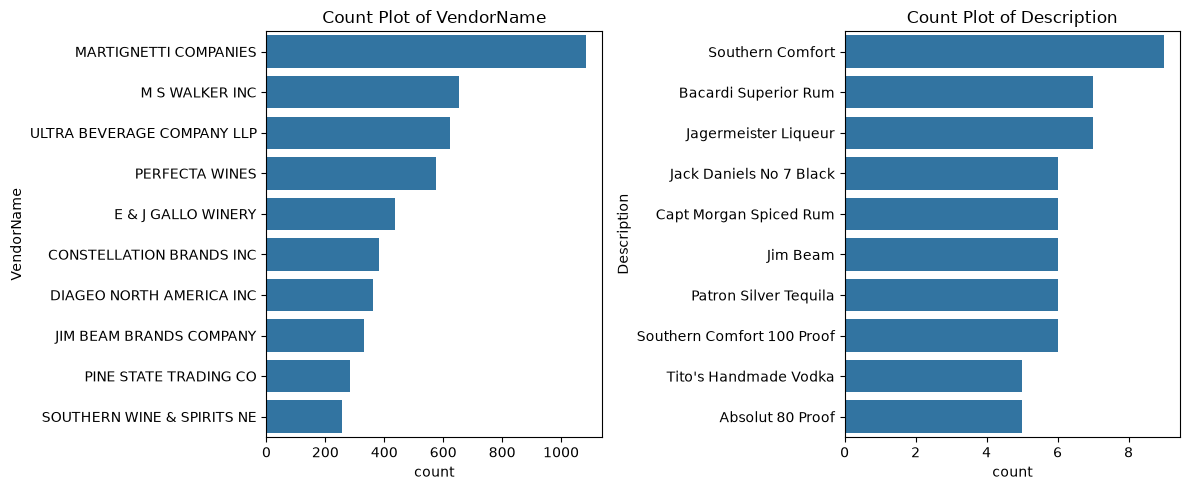

In [21]:
# Count Plots for Categorical Columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10]) # Top 10 categories
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()


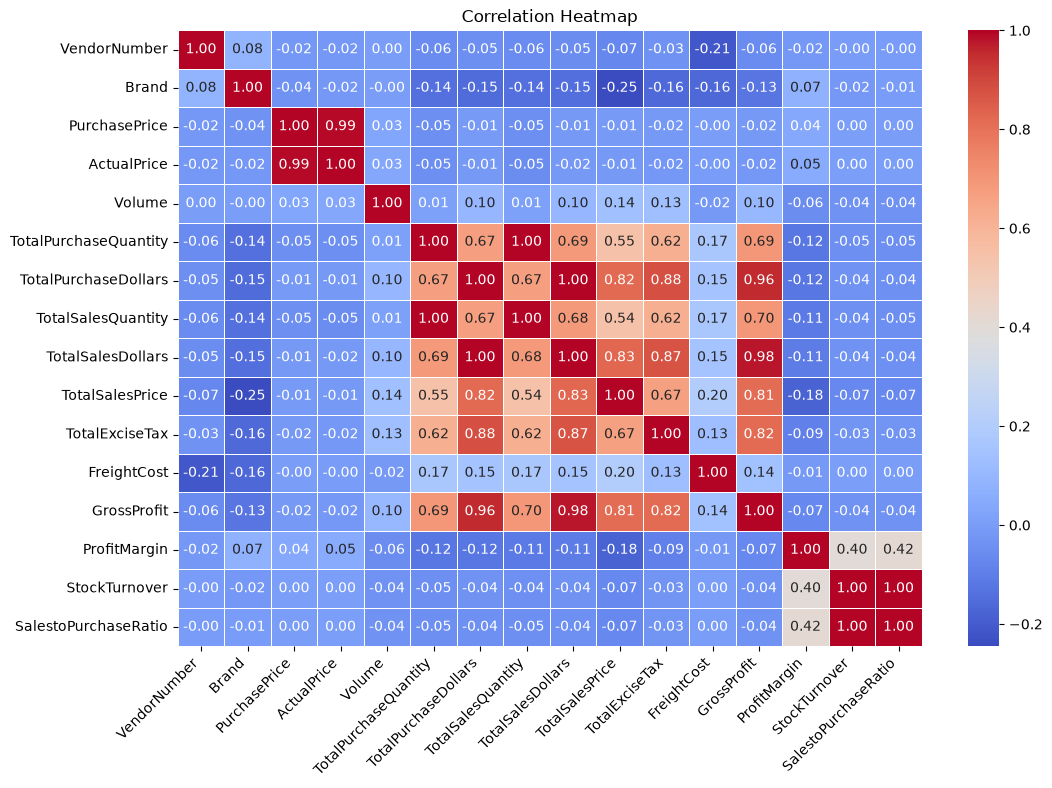

In [23]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
# Rotate the x-axis labels by 45 degrees
plt.xticks(rotation=45, ha='right')
plt.show()

### Key Business Insights from Correlation Analysis

* **Demand & Purchasing are Perfectly Synced:** There is a near-perfect correlation (1.00) between how much we buy (`TotalPurchaseQuantity`) and how much we sell (`TotalSalesQuantity`). This confirms a highly efficient, demand-driven inventory model with very little wasted purchasing.
* **Volume is the True Profit Engine:** Interestingly, a single item's base cost (`PurchasePrice`) has almost zero impact on total revenue or gross profit (-0.01 to -0.02). Instead, `GrossProfit` is overwhelmingly driven by overall sales volume (0.96+), meaning the bottom line relies on moving units rather than relying on high-ticket items.
* **Margin Squeeze on Premium Sales:** While our baseline markup strategy is incredibly consistent (0.99 correlation between `PurchasePrice` and `ActualPrice`), there is a notable negative correlation (-0.18) between `ProfitMargin` and `TotalSalesPrice`. This suggests we face competitive pricing pressures as total sale values increase, forcing us to accept slightly lower margins to close bigger sales.
* **Fast Movers are High Earners:** `StockTurnover` shows a healthy positive correlation (0.40) with `ProfitMargin`. This indicates that our faster-moving inventory doesn't just sell quickly—it also yields healthier profit margins, making these high-velocity items the most valuable assets in the catalog.
* **Freight Costs are Disconnected:** `FreightCost` shows remarkably weak correlations with both sales and purchase volumes. This implies that shipping expenses are likely influenced by external factors like flat rates, logistics routing, or distance, rather than scaling cleanly with the actual size of the orders.

# <span style="color: gold;">Data Analysis</span>

We need to identify the brands which need promotional or pricing adjustment, which exhibit lower sales performance but higher profit margins.

In [48]:
brand_performance = df.groupby('Description').agg({'TotalSalesDollars': 'sum', 'ProfitMargin': 'mean'}).reset_index()

In [30]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [33]:
low_sales_threshold.round(2) 


np.float64(560.3)

In [35]:
high_margin_threshold.round(2)


np.float64(64.97)

In [42]:
#filter brands with low sales but high margin
target_brands = brand_performance[(brand_performance['TotalSalesDollars'] <=low_sales_threshold) &
                                 (brand_performance['ProfitMargin'] >= high_margin_threshold)]
print("Brand with low sales but high profit margin")
display(target_brands.sort_values('TotalSalesDollars'))

Brand with low sales but high profit margin


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.47
2369,Debauchery Pnt Nr,11.58,65.98
2070,Concannon Glen Ellen Wh Zin,15.95,83.45
2188,Crown Royal Apple,27.86,89.81
6237,Sauza Sprklg Wild Berry Marg,27.96,82.15
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.75
2271,Dad's Hat Rye Whiskey,538.89,81.85
57,A Bichot Clos Marechaudes,539.94,67.74
6245,Sbragia Home Ranch Merlot,549.75,66.44


In [49]:
brand_performance=brand_performance[brand_performance['TotalSalesDollars']<10000]

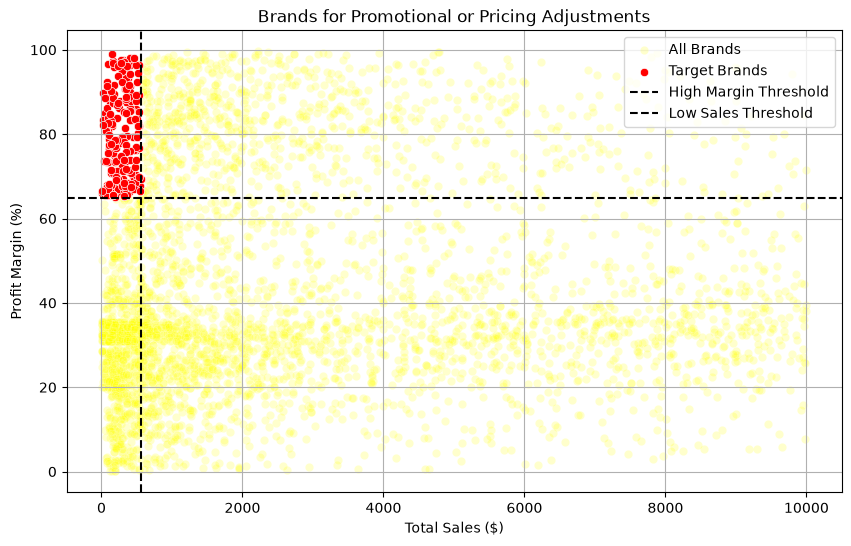

In [51]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color="yellow", label="All Brands", alpha = 0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color="red", label="Target Brands")

plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

**which vendor and brand demonstrate the highiest sales performance**

In [64]:
# top vendors and brands by sales performance
top_vendors = df.groupby('VendorName')['TotalSalesDollars'].sum().nlargest(10)
top_brands = df.groupby('Description')['TotalSalesDollars'].sum().nlargest(10)

# Apply your custom formatting function to the output
top_vendors.apply(format_dollars)

VendorName
DIAGEO NORTH AMERICA INC      $67.99M
MARTIGNETTI COMPANIES         $39.33M
PERNOD RICARD USA             $32.06M
JIM BEAM BRANDS COMPANY       $31.42M
BACARDI USA INC               $24.85M
CONSTELLATION BRANDS INC      $24.22M
E & J GALLO WINERY            $18.40M
BROWN-FORMAN CORP             $18.25M
ULTRA BEVERAGE COMPANY LLP    $16.50M
M S WALKER INC                $14.71M
Name: TotalSalesDollars, dtype: str

In [60]:
def format_dollars(x):
    """Formats a number into a readable dollar string with M or K suffixes."""
    if x >= 1_000_000:
        return f"${x / 1_000_000:.2f}M"
    elif x >= 1_000:
        return f"${x / 1_000:.1f}K"
    else:
        return f"${x:.2f}"

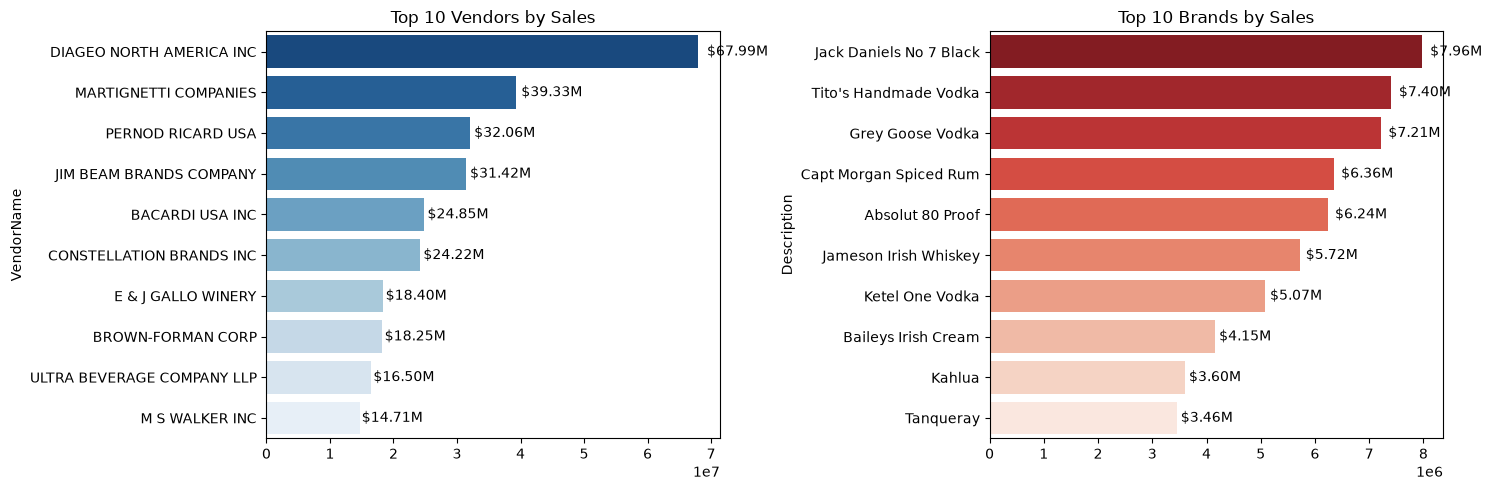

In [62]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

**Which Vendor contributes most to Total Purchase Dollars**

In [70]:
df.columns

Index(['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePrice',
       'ActualPrice', 'Volume', 'TotalPurchaseQuantity',
       'TotalPurchaseDollars', 'TotalSalesQuantity', 'TotalSalesDollars',
       'TotalSalesPrice', 'TotalExciseTax', 'FreightCost', 'GrossProfit',
       'ProfitMargin', 'StockTurnover', 'SalestoPurchaseRatio'],
      dtype='str')

In [72]:
vendor_performance = df.groupby('VendorName').agg({
            'TotalPurchaseDollars':'sum',
            'GrossProfit' : 'sum',
             'TotalSalesDollars': 'sum'
}).reset_index()

In [85]:
vendor_performance['PurchaseContribution%']=vendor_performance['TotalSalesDollars']/vendor_performance['TotalSalesDollars'].sum()*100

In [79]:
vendor_performance=vendor_performance.sort_values('PurchaseContribution%', ascending = False)


In [86]:
#Display top performing vendors
top_vendors = vendor_performance.head(10)
top_vendors['TotalPurchaseDollars']=top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit']=top_vendors['GrossProfit'].apply(format_dollars)
top_vendors['TotalSalesDollars']=top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors


,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,$50.10M,$17.89M,$67.99M,15.40
57,MARTIGNETTI COMPANIES,$25.50M,$13.83M,$39.33M,8.91
68,PERNOD RICARD USA,$23.85M,$8.21M,$32.06M,7.26
46,JIM BEAM BRANDS COMPANY,$23.49M,$7.93M,$31.42M,7.12
6,BACARDI USA INC,$17.43M,$7.42M,$24.85M,5.63
20,CONSTELLATION BRANDS INC,$15.27M,$8.95M,$24.22M,5.49
30,E & J GALLO WINERY,$12.07M,$6.33M,$18.40M,4.17
11,BROWN-FORMAN CORP,$13.24M,$5.01M,$18.25M,4.13
106,ULTRA BEVERAGE COMPANY LLP,$11.17M,$5.34M,$16.50M,3.74
53,M S WALKER INC,$9.76M,$4.94M,$14.71M,3.33


In [87]:
top_vendors['CumulativePerformance']=top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,CumulativePerformance
25,DIAGEO NORTH AMERICA INC,$50.10M,$17.89M,$67.99M,15.40,15.40
57,MARTIGNETTI COMPANIES,$25.50M,$13.83M,$39.33M,8.91,24.31
68,PERNOD RICARD USA,$23.85M,$8.21M,$32.06M,7.26,31.58
46,JIM BEAM BRANDS COMPANY,$23.49M,$7.93M,$31.42M,7.12,38.70
6,BACARDI USA INC,$17.43M,$7.42M,$24.85M,5.63,44.33
20,CONSTELLATION BRANDS INC,$15.27M,$8.95M,$24.22M,5.49,49.81
30,E & J GALLO WINERY,$12.07M,$6.33M,$18.40M,4.17,53.98
11,BROWN-FORMAN CORP,$13.24M,$5.01M,$18.25M,4.13,58.12
106,ULTRA BEVERAGE COMPANY LLP,$11.17M,$5.34M,$16.50M,3.74,61.85
53,M S WALKER INC,$9.76M,$4.94M,$14.71M,3.33,65.19


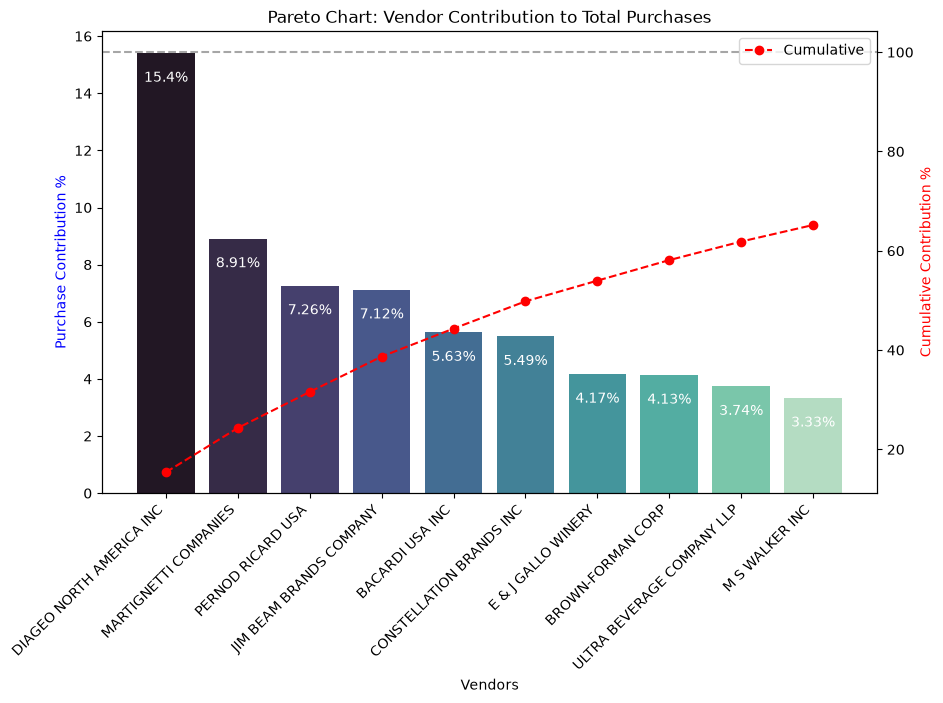

In [90]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution%
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'], palette="mako", ax=ax1)

for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value - 1, str(round(value, 2)) + '%', ha='center', fontsize=10, color='white')

# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['CumulativePerformance'], color='red', marker='o', linestyle='dashed', label='Cumulative')

# Updated line to tilt the x-axis labels by 45 degrees
ax1.set_xticklabels(top_vendors['VendorName'], rotation=45, ha='right')

ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.show()

**How Much of Total Procurment Dependant upon Top contributors**

In [96]:
print(f"total contribution by top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2) }%")

total contribution by top 10 vendors is 65.19%


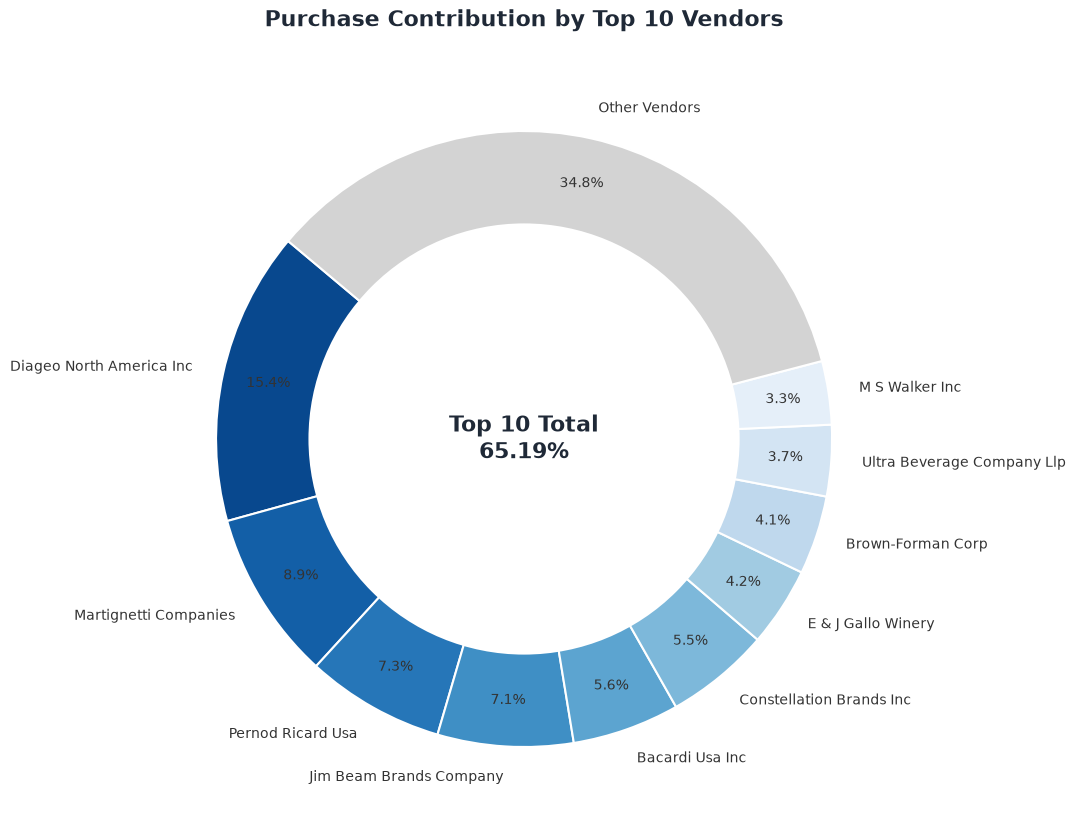

In [100]:
# 1. Clean up labels to Title Case for a more professional look
cleaned_vendors = [vendor.title() for vendor in top_vendors['VendorName'].values]
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)

total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors"
cleaned_vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# 2. Set up a professional color palette (Shades of Blue for top 10, Grey for "Other")
colors = sns.color_palette("Blues_r", len(cleaned_vendors) - 1).as_hex()
colors.append("#d3d3d3") # Light grey for "Other Vendors"

# Donut Chart
fig, ax = plt.subplots(figsize=(10, 10))

# 3. Create the pie chart with improved styling
wedges, texts, autotexts = ax.pie(
    purchase_contributions, 
    labels=cleaned_vendors, 
    autopct='%1.1f%%', 
    startangle=140, 
    pctdistance=0.85, 
    colors=colors,
    textprops={'fontsize': 10, 'color': '#333333'}, # Softer charcoal text for labels
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5} # White borders between slices
)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(0, 0, f"Top 10 Total\n{total_contribution:.2f}%", 
         fontsize=16, fontweight='bold', color='#1f2937', ha='center', va='center')

# Professional Title
plt.title("Purchase Contribution by Top 10 Vendors", 
          fontsize=16, fontweight='bold', color='#1f2937', pad=20)

plt.show()

**Does purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost savings?**

In [101]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [104]:
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio,UnitPurchasePrice,OrderSize
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.00,145080,3811251.60,142049.00,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.30,0.98,1.34,26.27,Large
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.00,164038,3804041.22,160247.00,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.06,0.98,1.27,23.19,Large
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.00,187407,3418303.68,187140.00,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.68,1.00,1.33,18.24,Large
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.00,201682,3261197.94,200412.00,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.14,0.99,1.37,16.17,Large
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.00,138109,3023206.01,135838.00,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.41,0.98,1.40,21.89,Large


In [102]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])

In [103]:
df["OrderSize"]

0       Large
1       Large
2       Large
3       Large
4       Large
        ...  
8559    Small
8560    Small
8561    Small
8562    Small
8563    Small
Name: OrderSize, Length: 8564, dtype: category
Categories (3, str): ['Small' < 'Medium' < 'Large']

In [107]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.07
Medium,15.49
Large,10.78


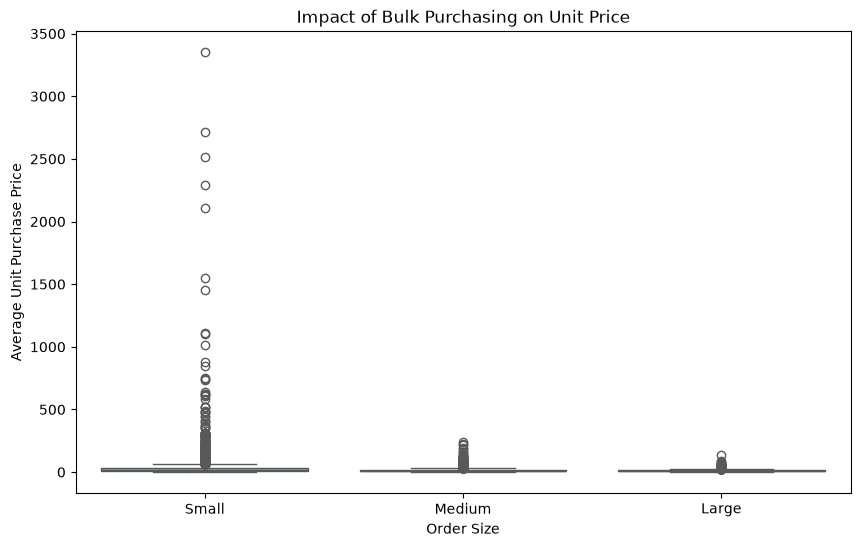

In [108]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

* Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.
* The price difference between Small and Large orders is substantial (~72% reduction in unit cost)
* This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit revenue.

**which vendors have low inventory turnover indicating excess stock and slow moving products**

In [120]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover', ascending =True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.62
HIGHLAND WINE MERCHANTS LLC,0.71
PARK STREET IMPORTS LLC,0.75
Circa Wines,0.76
Dunn Wine Brokers,0.77
CENTEUR IMPORTS LLC,0.77
SMOKY QUARTZ DISTILLERY LLC,0.78
TAMWORTH DISTILLING,0.80
THE IMPORTED GRAPE LLC,0.81


**How much capital is locked into unsold inventory and which vendor contribute the most to it**

In [124]:
df['UnsoldInventoryValue'] = (df['TotalPurchaseQuantity'] - df['TotalSalesQuantity']) * df['PurchasePrice']
print(" Total Capital Locked Into Unsold Inventory : " ,format_dollars(df['UnsoldInventoryValue'].sum()))

 Total Capital Locked Into Unsold Inventory :  $2.71M


In [133]:
inventory_locked_per_vendor = df.groupby('VendorName')['UnsoldInventoryValue'].sum().reset_index()
#sort Values with Highest inventory locked 
inventory_locked_per_vendor=inventory_locked_per_vendor.sort_values('UnsoldInventoryValue', ascending = False)
inventory_locked_per_vendor['UnsoldInventoryValue'] =inventory_locked_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_locked_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,$722.2K
46,JIM BEAM BRANDS COMPANY,$554.7K
68,PERNOD RICARD USA,$470.6K
116,WILLIAM GRANT & SONS INC,$402.0K
30,E & J GALLO WINERY,$228.3K
79,SAZERAC CO INC,$198.4K
11,BROWN-FORMAN CORP,$177.7K
20,CONSTELLATION BRANDS INC,$133.6K
61,MOET HENNESSY USA INC,$126.5K
77,REMY COINTREAU USA INC,$118.6K


**What is the 95% confidance intervals for profit margin of top performing and low performing vendors**

In [134]:
top_threshold = df['TotalSalesDollars'].quantile(.75)
low_threshold = df['TotalSalesDollars'].quantile(.25)

In [136]:
top_vendors = df[df['TotalSalesDollars'] >= top_threshold]['ProfitMargin'].dropna()
low_vendors = df[df['TotalSalesDollars'] <= low_threshold]['ProfitMargin'].dropna()

In [137]:
low_vendors 

5631    4.11
5652    6.15
5701   12.01
5704    1.68
5724    7.24
        ... 
8559   83.45
8560   96.44
8561   25.25
8562   98.97
8563   99.17
Name: ProfitMargin, Length: 2141, dtype: float64

In [138]:
#create a function to calculate confidance interval
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.18
Low Vendors 95% CI: (40.50, 42.64), Mean: 41.57


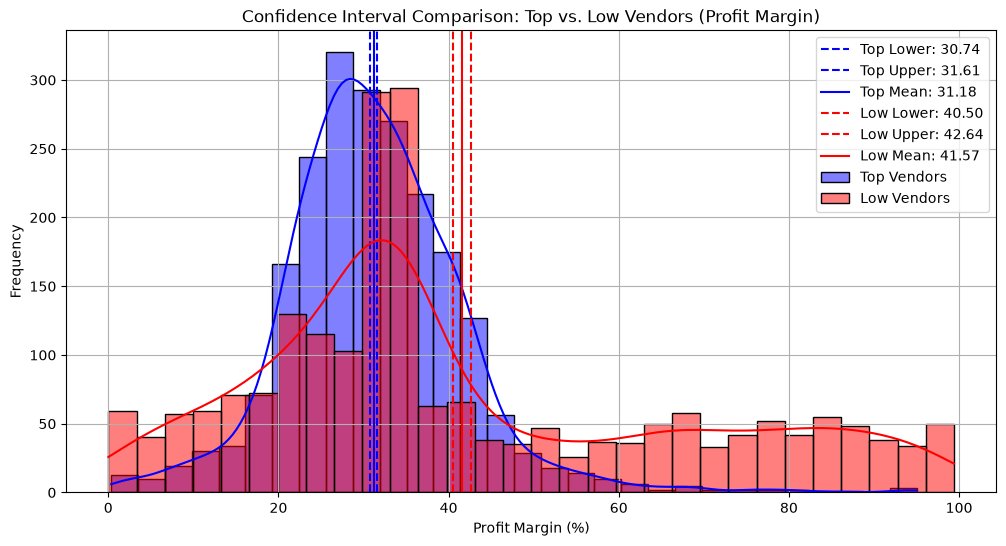

In [139]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

### Key Strategic Insights: Top vs. Low-Performing Vendors

* **1. The Volume vs. Margin Trade-off:** The data reveals a clear inverse relationship between sales volume and profit margins. Top-performing vendors average a highly consistent 31.18% margin (95% CI: 30.74% to 31.61%), whereas low-performing vendors maintain significantly higher margins averaging 41.57% (95% CI: 40.50% to 42.64%), likely due to premium pricing on specialty items or lower operational costs.
* **2. Strategies for High-Performing Vendors:** The exceptionally narrow confidence interval for our top vendors indicates a highly predictable and standardized pricing strategy. Because this baseline is so stable, we can safely drive further profitability by exploring selective price adjustments, careful cost optimization, or strategic product bundling without risking our core revenue stream.
* **3. Strategies for Low-Performing Vendors:** The wider margin distribution for low vendors (stretching all the way to 100%) highlights a "Wild West" of lucrative, niche products. However, because their overall sales volume is holding them back, we need to deploy better marketing, competitive pricing adjustments, or improved distribution strategies to unlock their true value.
* **4. The Ultimate Growth Opportunity:** While the business relies on a high-volume, moderate-margin model for the bulk of its gross profit, the highest untapped potential lies at the bottom. By finding ways to marginally increase the sales velocity of our high-margin "Low Vendors" (through targeted promotions or better placement), we can achieve a disproportionately large boost to our bottom line.

### Is there a significant difference in profit margins between top-performing and low-performing vendors?

Hypothesis:

H₀ (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

H₁ (Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.

In [140]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H₀: No significant difference in profit margins.")

T-Statistic: -17.6693, P-Value: 0.0000
Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.
